In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_customer_data.csv to cleaned_customer_data.csv
Saving cleaned_inventory_data.csv to cleaned_inventory_data.csv
Saving cleaned_product_data.csv to cleaned_product_data.csv
Saving cleaned_sales_data.csv to cleaned_sales_data.csv


In [3]:
customer_df = pd.read_csv("cleaned_customer_data.csv")
inventory_df = pd.read_csv("cleaned_inventory_data.csv")
product_df = pd.read_csv("cleaned_product_data.csv")
sales_df = pd.read_csv("cleaned_sales_data.csv")

print("All cleaned datasets loaded successfully!")

All cleaned datasets loaded successfully!


In [4]:
print("Customer Data:", customer_df.shape)
print("Inventory Data:", inventory_df.shape)
print("Product Data:", product_df.shape)
print("Sales Data:", sales_df.shape)

Customer Data: (500, 13)
Inventory Data: (4803, 8)
Product Data: (80, 6)
Sales Data: (5000, 19)


In [5]:
sales_df.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Name,Category,Quantity,Selling_Price,Cost_Price,Discount_Percent,Gross_Sales,Discount_Amount,Revenue,Total_Cost,Profit,Profit_Margin_Percent,Payment_Mode,Sales_Channel,City
0,ORD100000,2026-02-22,C1082,P150,LED Bulb V3,Home,1,2960,2119,10.0,2960,296.0,2664.0,2119,545.0,20.46,Card,Online,Noida
1,ORD100001,2024-05-05,C1052,P174,Coffee V3,Grocery,1,1420,1012,15.0,1420,213.0,1207.0,1012,195.0,16.16,Cash,Online,Kanpur
2,ORD100002,2024-03-09,C1117,P158,Phone Case V2,Accessories,1,2660,1753,5.0,2660,133.0,2527.0,1753,774.0,30.63,UPI,Store,Kanpur
3,ORD100003,2025-07-12,C1166,P167,Desk Mat V2,Accessories,3,3170,2059,10.0,9510,951.0,8559.0,6177,2382.0,27.83,Card,Store,Lucknow
4,ORD100004,2025-02-07,C1028,P123,Office Chair V3,Office,3,4680,3454,10.0,14040,1404.0,12636.0,10362,2274.0,18.00,Net Banking,Online,Lucknow


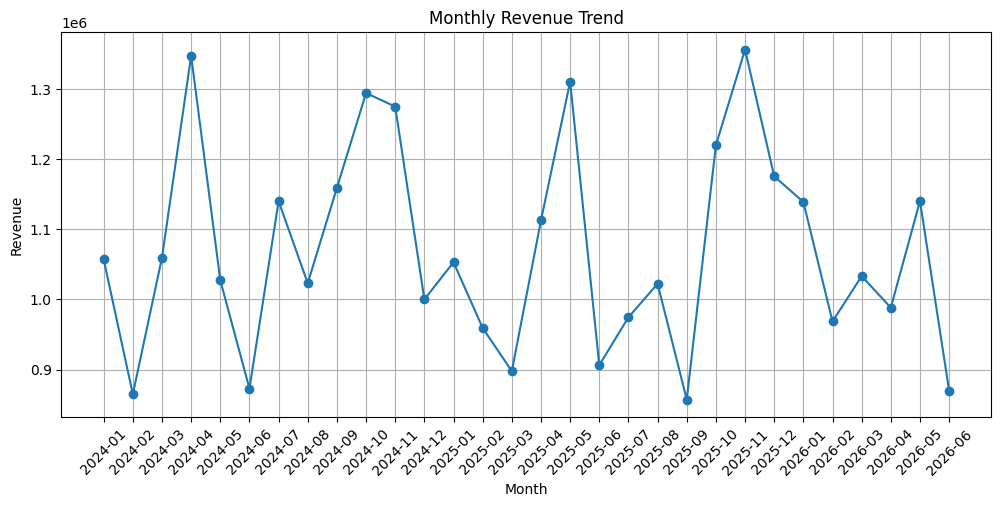

In [6]:
sales_df["Order_Date"] = pd.to_datetime(sales_df["Order_Date"])

monthly_revenue = sales_df.groupby(
    sales_df["Order_Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

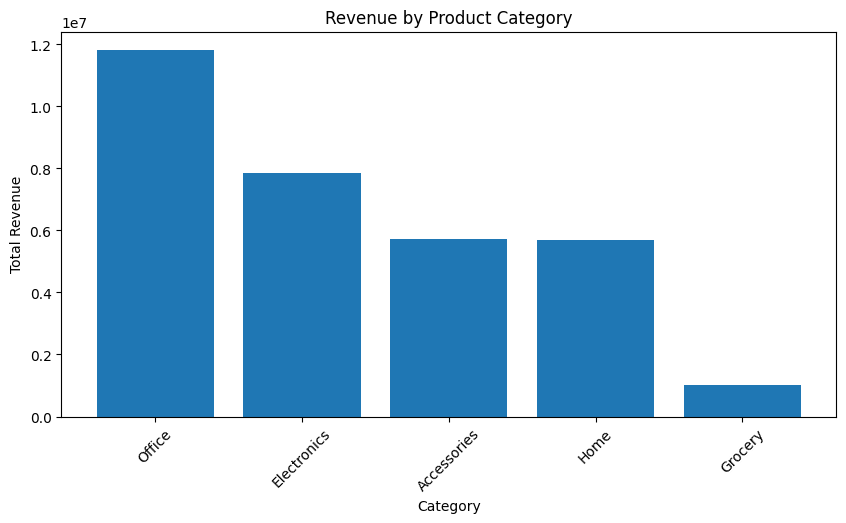

In [7]:
category_revenue = sales_df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(category_revenue.index, category_revenue.values)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

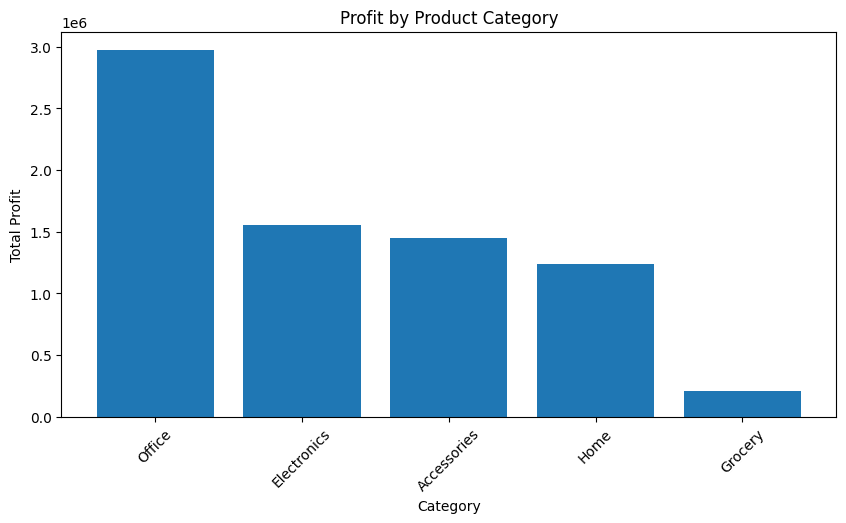

In [10]:
category_profit = sales_df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(category_profit.index, category_profit.values)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.show()

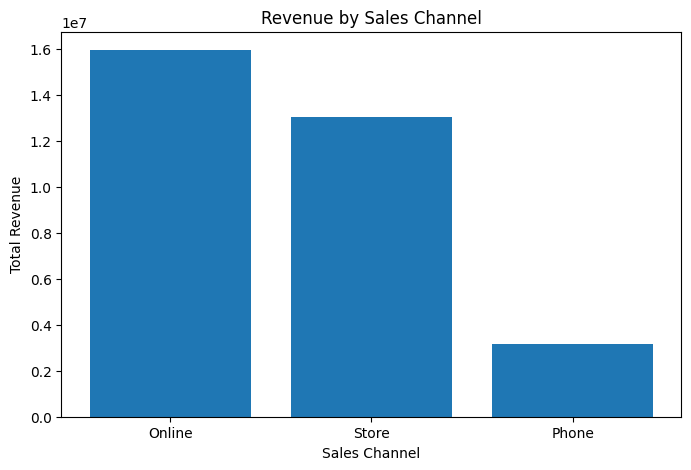

In [11]:
channel_revenue = sales_df.groupby("Sales_Channel")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(channel_revenue.index, channel_revenue.values)

plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Revenue")

plt.show()

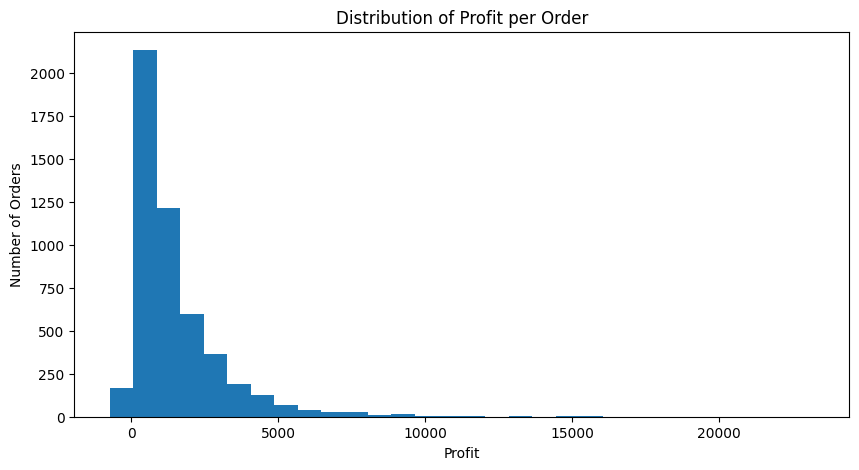

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(sales_df["Profit"], bins=30)

plt.title("Distribution of Profit per Order")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")

plt.show()

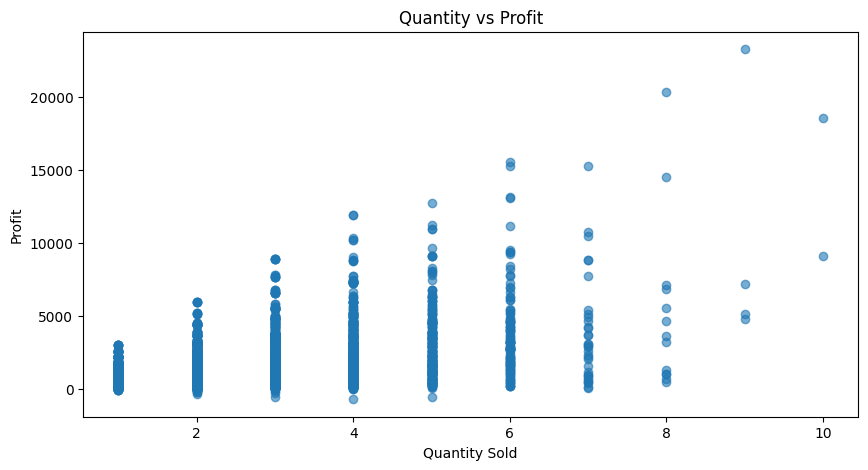

In [13]:
plt.figure(figsize=(10, 5))
plt.scatter(sales_df["Quantity"], sales_df["Profit"], alpha=0.6)

plt.title("Quantity vs Profit")
plt.xlabel("Quantity Sold")
plt.ylabel("Profit")

plt.show()

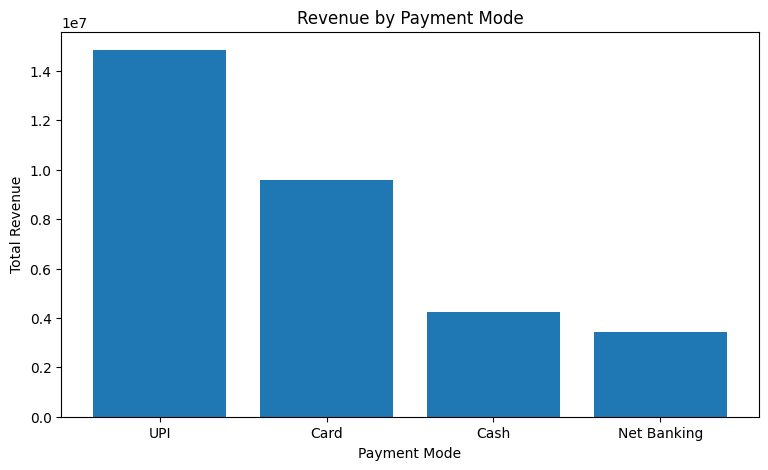

In [14]:
payment_revenue = sales_df.groupby("Payment_Mode")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(payment_revenue.index, payment_revenue.values)

plt.title("Revenue by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Revenue")

plt.show()

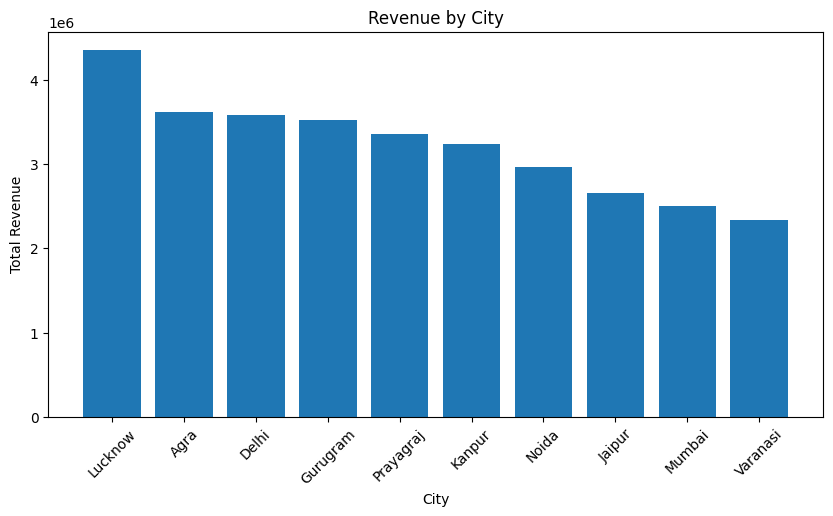

In [15]:
city_revenue = sales_df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(city_revenue.index, city_revenue.values)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()


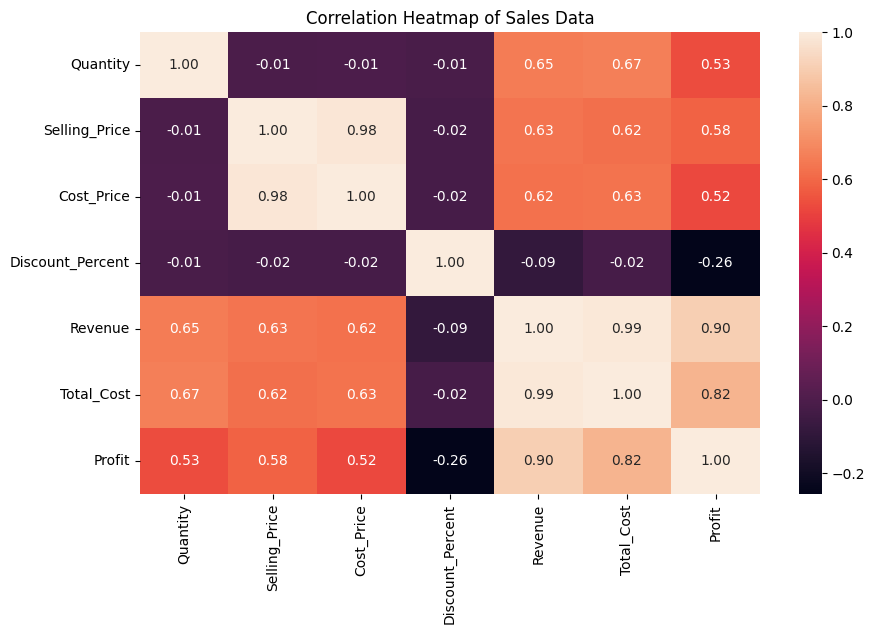

In [16]:
numeric_data = sales_df[
    ["Quantity", "Selling_Price", "Cost_Price",
     "Discount_Percent", "Revenue", "Total_Cost", "Profit"]
]

correlation = numeric_data.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, fmt=".2f")

plt.title("Correlation Heatmap of Sales Data")

plt.show()

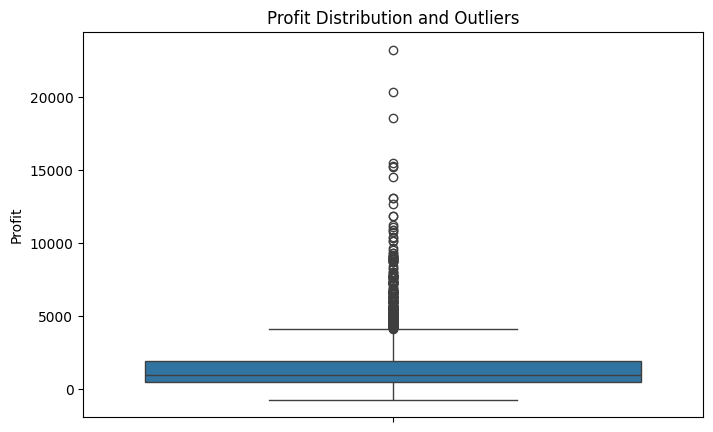

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=sales_df["Profit"])

plt.title("Profit Distribution and Outliers")
plt.ylabel("Profit")

plt.show()

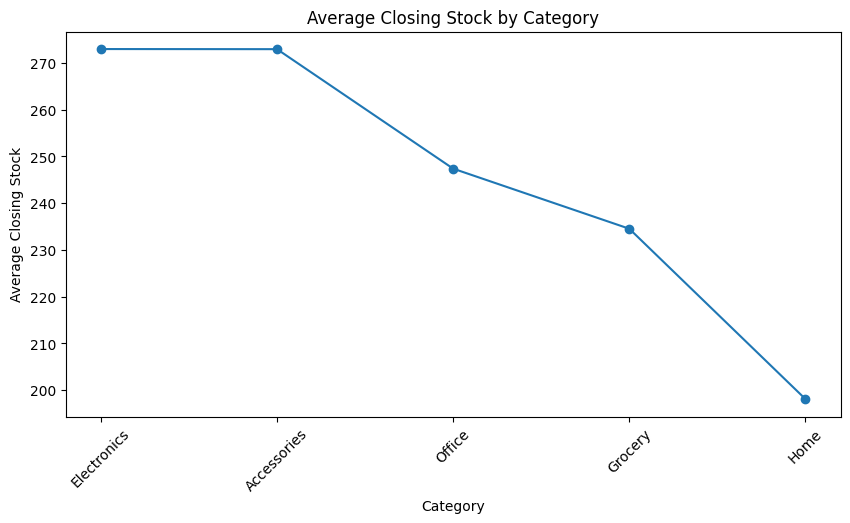

In [18]:
inventory_summary = inventory_df.groupby("Category")["Closing_Stock"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(inventory_summary.index, inventory_summary.values, marker="o")

plt.title("Average Closing Stock by Category")
plt.xlabel("Category")
plt.ylabel("Average Closing Stock")
plt.xticks(rotation=45)

plt.show()

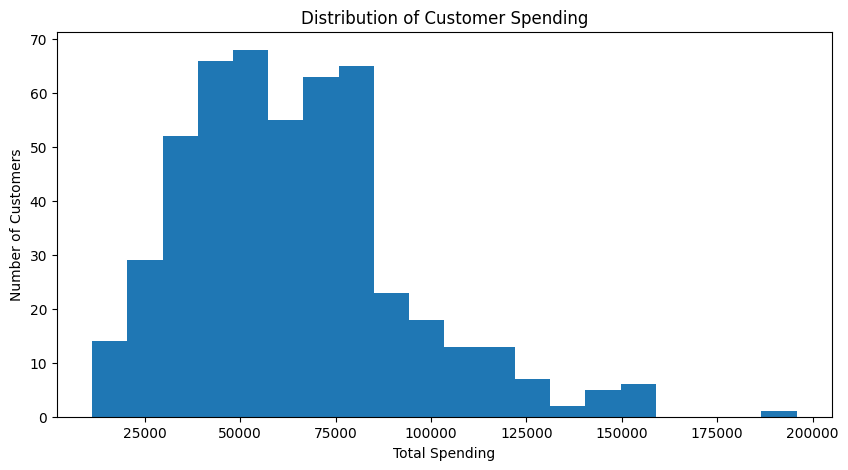

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(customer_df["Total_Spending"], bins=20)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

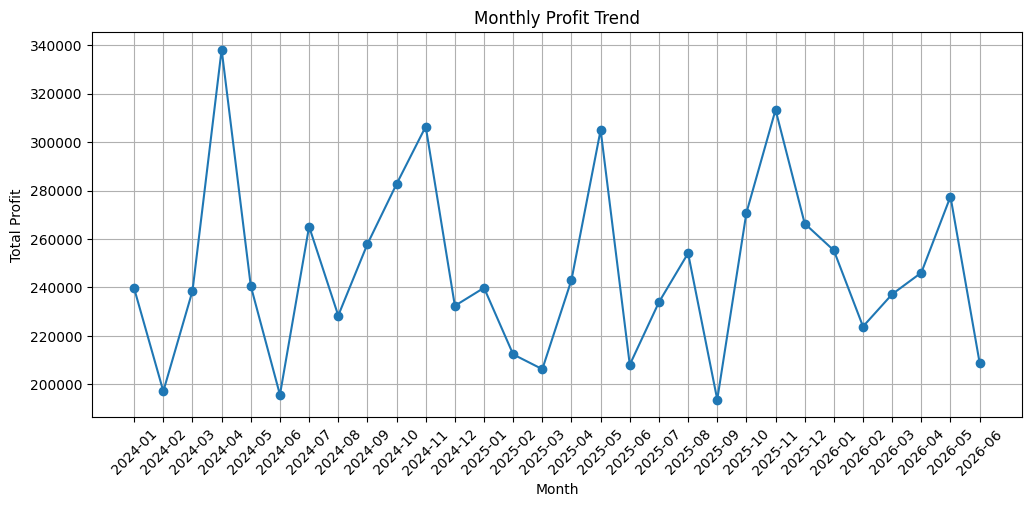

In [21]:
monthly_profit = sales_df.groupby(
    sales_df["Order_Date"].dt.to_period("M")
)["Profit"].sum()

monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_profit.index, monthly_profit.values, marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()


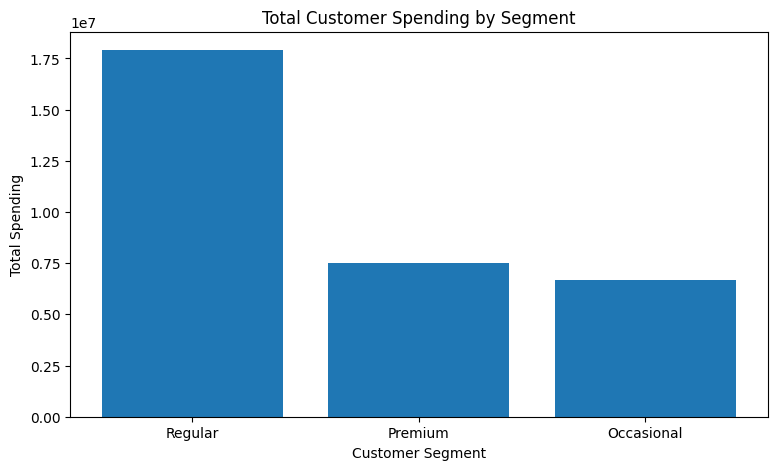

In [22]:
segment_revenue = customer_df.groupby("Customer_Segment")["Total_Spending"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(segment_revenue.index, segment_revenue.values)

plt.title("Total Customer Spending by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Spending")

plt.show()

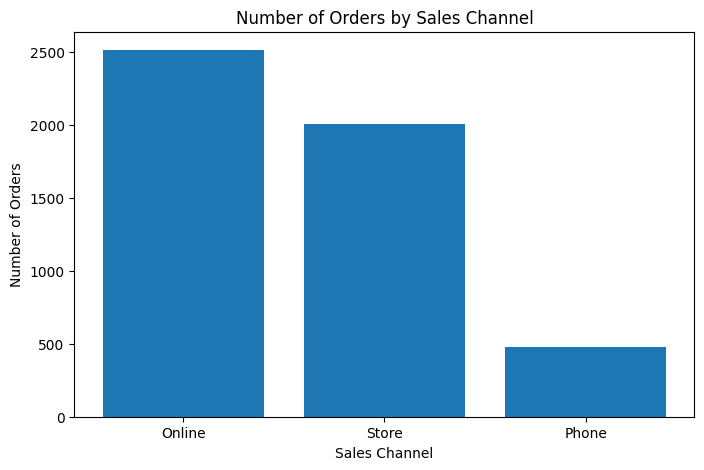

In [23]:
channel_orders = sales_df["Sales_Channel"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(channel_orders.index, channel_orders.values)

plt.title("Number of Orders by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Orders")

plt.show()


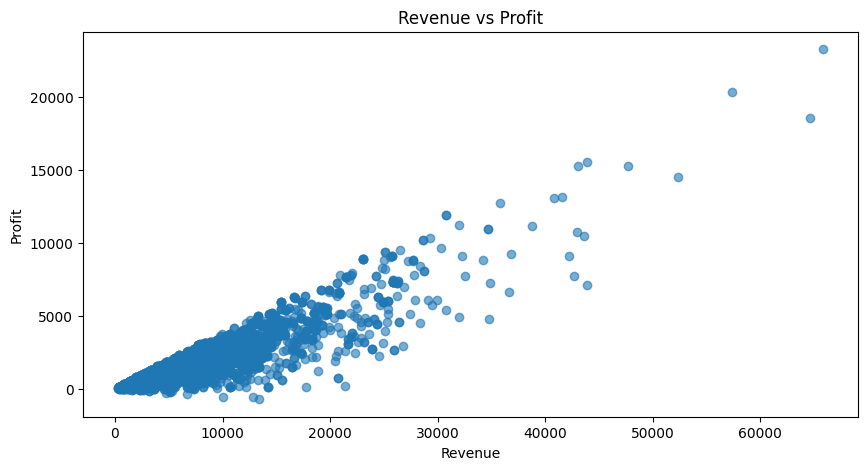

In [24]:
plt.figure(figsize=(10, 5))

plt.scatter(sales_df["Revenue"], sales_df["Profit"], alpha=0.6)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.show()

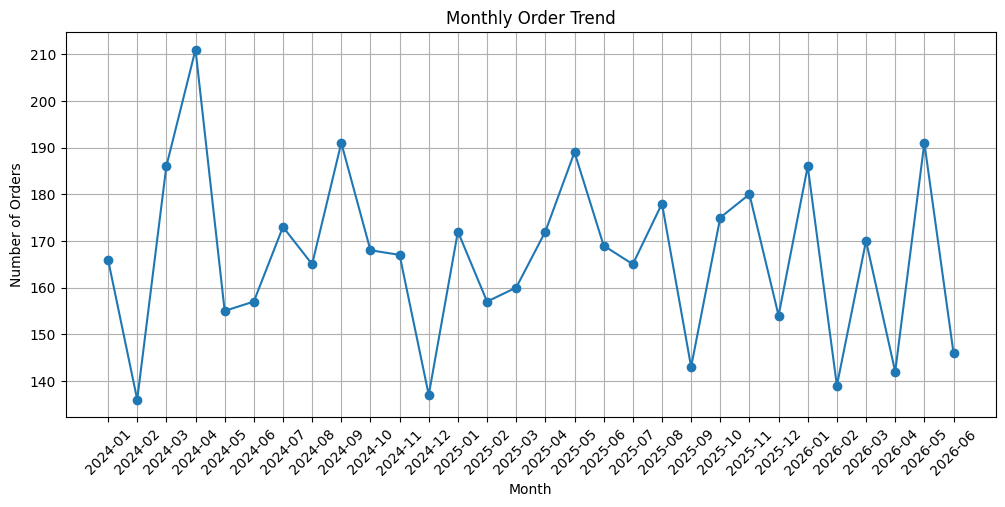

In [25]:
monthly_orders = sales_df.groupby(
    sales_df["Order_Date"].dt.to_period("M")
)["Order_ID"].count()

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders.index, monthly_orders.values, marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

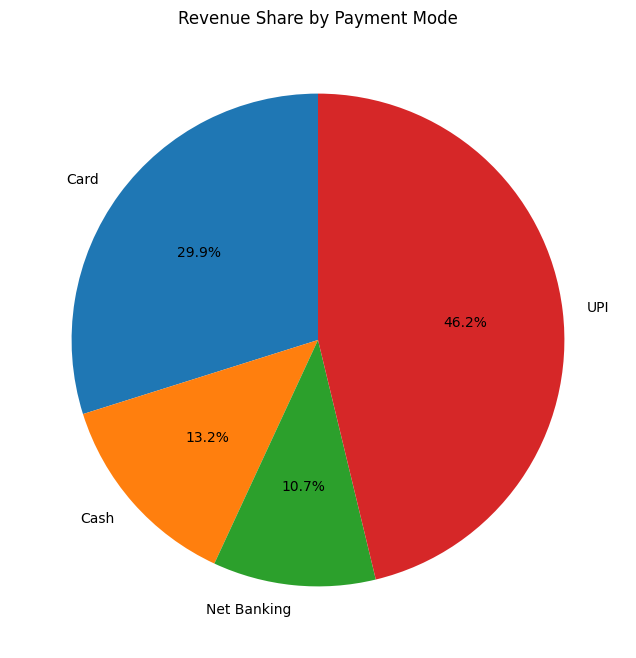

In [26]:
payment_revenue = sales_df.groupby("Payment_Mode")["Revenue"].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    payment_revenue.values,
    labels=payment_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Payment Mode")

plt.show()

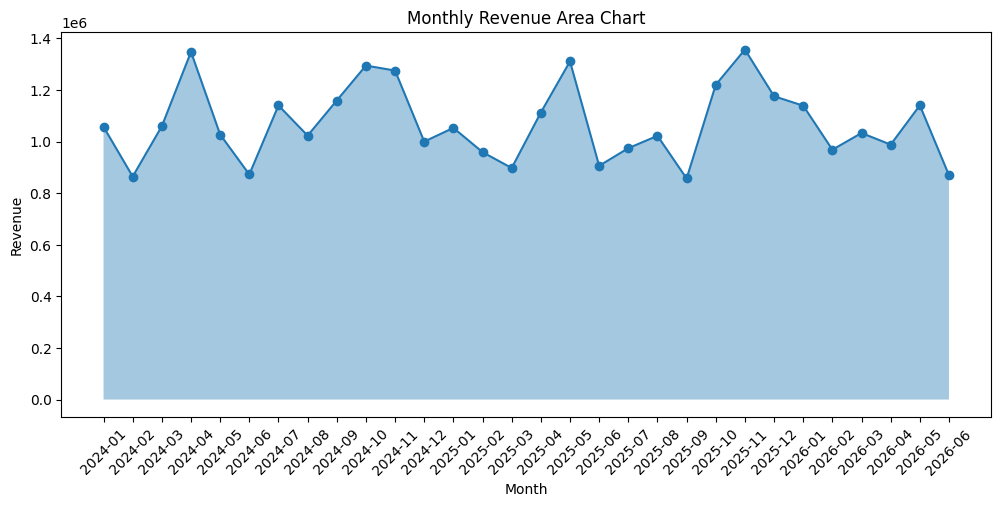

In [27]:
monthly_sales = sales_df.groupby(
    sales_df["Order_Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.fill_between(
    monthly_sales.index,
    monthly_sales.values,
    alpha=0.4
)

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Area Chart")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()


In [29]:
top_products = sales_df.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False).head(5)

print("Top 5 Products by Revenue:")
print(top_products)

Top 5 Products by Revenue:
Product_Name
Stapler V3              1156521.0
Printer Paper V3        1127665.0
Bluetooth Speaker V1    1055439.0
Office Chair V1          979336.0
Desk Lamp V2             929638.5
Name: Revenue, dtype: float64


In [30]:
loss_products = sales_df[sales_df["Profit"] < 0].groupby("Product_Name")["Profit"].sum().sort_values()

print("Loss-Making Products:")
print(loss_products.head(5))

Loss-Making Products:
Product_Name
Keyboard V3         -1638.0
Wireless Mouse V3   -1276.0
Power Bank V3        -864.0
Water Bottle V1      -228.0
Travel Pouch V3      -204.0
Name: Profit, dtype: float64


In [31]:
top_customers = customer_df.groupby("Customer_Name")["Total_Spending"].sum().sort_values(ascending=False).head(5)

print("Top 5 Customers by Spending:")
print(top_customers)

Top 5 Customers by Spending:
Customer_Name
Karan_128     195819.5
Aditi_443     157658.5
Aarav_492     153978.5
Nisha_134     153815.0
Ananya_292    153582.0
Name: Total_Spending, dtype: float64


In [32]:
churn_counts = customer_df["Churn_Status"].value_counts()

print("Customer Churn Status:")
print(churn_counts)


Customer Churn Status:
Churn_Status
No     369
Yes    131
Name: count, dtype: int64


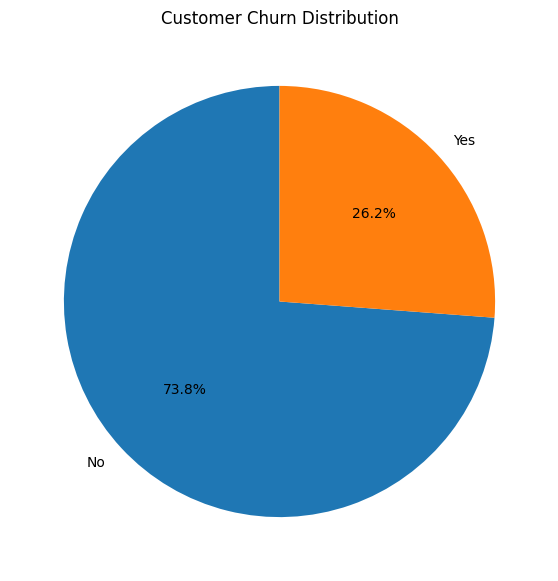

In [33]:
plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Distribution")

plt.show()


In [34]:
low_stock = inventory_df.groupby("Product_Name")["Closing_Stock"].mean().sort_values().head(5)

print("Top 5 Products with Lowest Average Closing Stock:")
print(low_stock)


Top 5 Products with Lowest Average Closing Stock:
Product_Name
Water Bottle V2    117.047619
LED Bulb V2        123.127273
Stapler V1         123.234375
Tea V3             128.742424
Notebook V3        130.161290
Name: Closing_Stock, dtype: float64


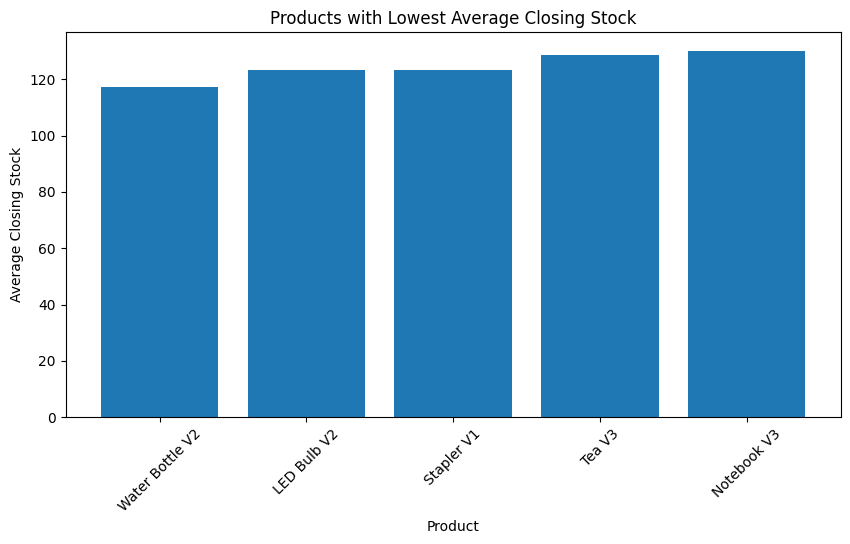

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(low_stock.index, low_stock.values)

plt.title("Products with Lowest Average Closing Stock")
plt.xlabel("Product")
plt.ylabel("Average Closing Stock")
plt.xticks(rotation=45)

plt.show()

In [36]:
category_margin = sales_df.groupby("Category")["Profit_Margin_Percent"].mean().sort_values(ascending=False)

print("Average Profit Margin by Category:")
print(category_margin)


Average Profit Margin by Category:
Category
Office         24.406693
Accessories    22.970936
Home           21.374875
Electronics    20.075929
Grocery        19.300607
Name: Profit_Margin_Percent, dtype: float64


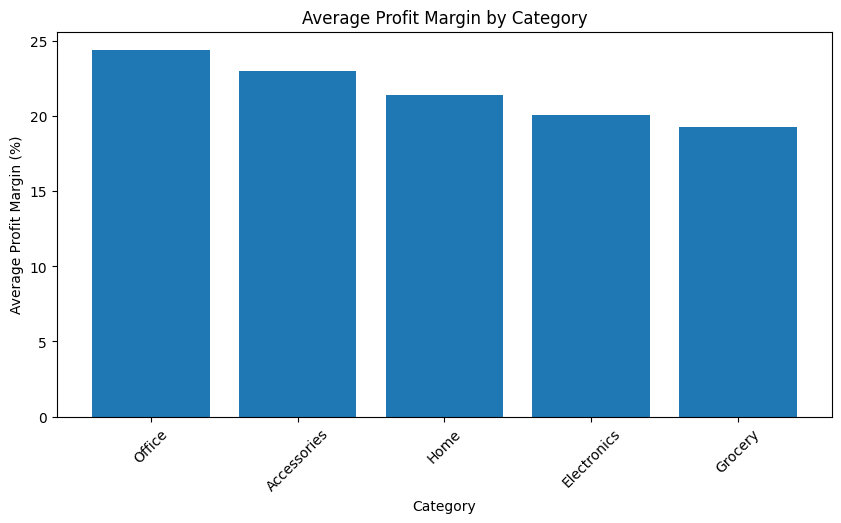

In [37]:
plt.figure(figsize=(10, 5))

plt.bar(category_margin.index, category_margin.values)

plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit Margin (%)")
plt.xticks(rotation=45)

plt.show()

In [39]:
top_profit_products = sales_df.groupby("Product_Name")["Profit"].sum().sort_values(ascending=False).head(5)

print("Top 5 Products by Profit:")
print(top_profit_products)

Top 5 Products by Profit:
Product_Name
Printer Paper V3        375118.0
Stapler V3              355185.0
Bluetooth Speaker V1    271854.0
Desk Lamp V2            256287.5
Stapler V1              255834.0
Name: Profit, dtype: float64


In [40]:
print("===== BizInsight-AI Business Insights =====\n")

print("1. Top Revenue Product:")
print(top_products.head(1))

print("\n2. Top Profit Product:")
print(top_profit_products.head(1))

print("\n3. Highest Loss-Making Product:")
print(loss_products.head(1))

print("\n4. Customer Churn:")
print(churn_counts)

print("\n5. Lowest Stock Products:")
print(low_stock)

print("\n6. Highest Profit Margin Category:")
print(category_margin.head(1))


===== BizInsight-AI Business Insights =====

1. Top Revenue Product:
Product_Name
Stapler V3    1156521.0
Name: Revenue, dtype: float64

2. Top Profit Product:
Product_Name
Printer Paper V3    375118.0
Name: Profit, dtype: float64

3. Highest Loss-Making Product:
Product_Name
Keyboard V3   -1638.0
Name: Profit, dtype: float64

4. Customer Churn:
Churn_Status
No     369
Yes    131
Name: count, dtype: int64

5. Lowest Stock Products:
Product_Name
Water Bottle V2    117.047619
LED Bulb V2        123.127273
Stapler V1         123.234375
Tea V3             128.742424
Notebook V3        130.161290
Name: Closing_Stock, dtype: float64

6. Highest Profit Margin Category:
Category
Office    24.406693
Name: Profit_Margin_Percent, dtype: float64


In [41]:
import plotly.express as px

fig = px.line(
    monthly_revenue.reset_index(),
    x="Order_Date",
    y="Revenue",
    title="Interactive Monthly Revenue Trend",
    markers=True
)

fig.show()

In [42]:
profit_values = np.array(sales_df["Profit"])

print("Average Profit:", np.mean(profit_values))
print("Maximum Profit:", np.max(profit_values))
print("Minimum Profit:", np.min(profit_values))

Average Profit: 1483.5489
Maximum Profit: 23238.0
Minimum Profit: -728.0


In [43]:
print("===== Visualization Interpretation =====\n")

print("1. Revenue Insight:")
print("The revenue analysis helps identify the highest-performing products and categories.")

print("\n2. Profit Insight:")
print("Profit analysis shows which products and categories contribute most to profitability.")

print("\n3. Customer Insight:")
print("Customer analysis shows spending patterns and identifies the proportion of churned customers.")

print("\n4. Inventory Insight:")
print("Inventory analysis identifies products with comparatively low stock levels that may require attention.")

print("\n5. Overall Business Insight:")
print("Combining revenue, profit, customer, and inventory visualizations helps identify business opportunities and areas requiring improvement.")

===== Visualization Interpretation =====

1. Revenue Insight:
The revenue analysis helps identify the highest-performing products and categories.

2. Profit Insight:
Profit analysis shows which products and categories contribute most to profitability.

3. Customer Insight:
Customer analysis shows spending patterns and identifies the proportion of churned customers.

4. Inventory Insight:
Inventory analysis identifies products with comparatively low stock levels that may require attention.

5. Overall Business Insight:
Combining revenue, profit, customer, and inventory visualizations helps identify business opportunities and areas requiring improvement.


In [44]:
print("===== BizInsight-AI Business Recommendations =====\n")

print("1. Product Recommendation:")
print("Stapler V3 generates the highest revenue, so its availability and sales should be maintained.")

print("\n2. Profit Recommendation:")
print("Printer Paper V3 generates the highest total profit and should be considered a strong-performing product.")

print("\n3. Loss Reduction Recommendation:")
print("Keyboard V3 shows the highest product-level loss. Its pricing, cost, discount, and sales strategy should be reviewed.")

print("\n4. Customer Recommendation:")
print("26.2% of customers are marked as churned. Customer retention strategies such as targeted offers and follow-up campaigns can be considered.")

print("\n5. Inventory Recommendation:")
print("Water Bottle V2 has the lowest average closing stock among the analyzed products. Its stock level should be monitored and restocking can be considered when demand is high.")

print("\n6. Profit Margin Recommendation:")
print("Office has the highest average profit margin at approximately 24.41%. The business can study its pricing and cost structure for possible improvement in other categories.")

===== BizInsight-AI Business Recommendations =====

1. Product Recommendation:
Stapler V3 generates the highest revenue, so its availability and sales should be maintained.

2. Profit Recommendation:
Printer Paper V3 generates the highest total profit and should be considered a strong-performing product.

3. Loss Reduction Recommendation:
Keyboard V3 shows the highest product-level loss. Its pricing, cost, discount, and sales strategy should be reviewed.

4. Customer Recommendation:
26.2% of customers are marked as churned. Customer retention strategies such as targeted offers and follow-up campaigns can be considered.

5. Inventory Recommendation:
Water Bottle V2 has the lowest average closing stock among the analyzed products. Its stock level should be monitored and restocking can be considered when demand is high.

6. Profit Margin Recommendation:
Office has the highest average profit margin at approximately 24.41%. The business can study its pricing and cost structure for possible 

In [45]:
print("===== Week 3 Final Validation =====\n")

print("✓ 8 visualization techniques completed")
print("✓ Matplotlib visualizations completed")
print("✓ Seaborn visualizations completed")
print("✓ Plotly interactive visualization completed")
print("✓ Pandas data analysis completed")
print("✓ NumPy numerical analysis completed")
print("✓ Business insights identified")
print("✓ Business recommendations generated")

print("\nWeek 3 Data Visualization and Reporting task completed successfully!")


===== Week 3 Final Validation =====

✓ 8 visualization techniques completed
✓ Matplotlib visualizations completed
✓ Seaborn visualizations completed
✓ Plotly interactive visualization completed
✓ Pandas data analysis completed
✓ NumPy numerical analysis completed
✓ Business insights identified
✓ Business recommendations generated

Week 3 Data Visualization and Reporting task completed successfully!
